In [11]:
from astropy.io import fits
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from collections import Counter

In [2]:
hdulist = fits.open('../../data/allStarLite-dr17-synspec_rev1.fits')
hdu1_data = hdulist[1].data
df4 = pd.DataFrame(hdu1_data.tolist(), columns=hdu1_data.names)



In [3]:
df = df4

In [4]:
df = df.drop_duplicates(subset='APOGEE_ID')

In [5]:
df.head()

,APOGEE_ID,TELESCOPE,FIELD,ALT_ID,RA,DEC,GLON,GLAT,J,J_ERR,...,NI_FE_ERR,NI_FE_FLAG,CU_FE,CU_FE_SPEC,CU_FE_ERR,CU_FE_FLAG,CE_FE,CE_FE_SPEC,CE_FE_ERR,CE_FE_FLAG
0,VESTA,apo1m,calibration,,NaN,NaN,292.219131,-30.602919,99.999001,0.000,...,0.010266,0,NaN,NaN,0.059403,2,NaN,NaN,NaN,64
1,2M00000002+7417074,apo25m,120+12,none,0.000103,74.285408,119.401807,11.767414,8.597000,0.039,...,0.010609,0,NaN,NaN,0.001221,2,NaN,NaN,NaN,64
2,2M00000019-1924498,apo25m,060-75,none,0.000832,-19.413851,63.394122,-75.906397,11.074000,0.022,...,0.013835,0,NaN,NaN,0.102594,2,NaN,NaN,NaN,64
3,2M00000032+5737103,apo25m,116-04,none,0.001335,57.619530,116.065371,-4.564768,10.905000,0.023,...,0.016555,0,NaN,NaN,0.123839,2,NaN,NaN,NaN,64
5,2M00000035-7323394,lco25m,SMC12,none,0.001467,-73.394287,307.939441,-43.230305,15.008000,0.045,...,0.053997,0,NaN,NaN,0.276795,2,-0.15516,-0.0995,0.146837,0


In [6]:
df_classes = pd.read_csv('../../data/classes.csv')

In [7]:
df_merged = pd.merge(df_classes, df, left_on='apogee_id', right_on='APOGEE_ID', how='inner')

In [8]:
variable_selection = ['apogee_id', "J", "H", "K","LOGG", "M_H", "VMICRO", "VMACRO", "VSINI", 'C_FE', 'CI_FE', 'N_FE', 'O_FE', 'NA_FE', 'MG_FE', 'AL_FE', 'SI_FE', 'S_FE', 'K_FE', 'CA_FE', 
    'TI_FE', 'TIII_FE', 'V_FE', 'CR_FE', 'MN_FE', 'CO_FE', 'NI_FE', 'CE_FE', 'FE_H', 
    'class_spectral', 'class_lum_logg', 'class_lum_jhk', 'class_lum_bins_logg', 'class_lum_bins_jhk', 'STARFLAGS',"ASPCAPFLAGS", "TEFF"]

In [9]:
sample = df_merged[variable_selection]

In [10]:
sample = sample.drop(columns=["VSINI", "TIII_FE", "CO_FE", "CE_FE"])

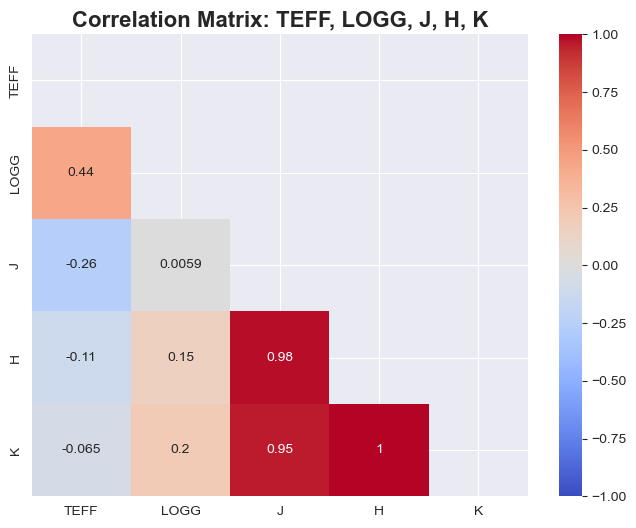

In [12]:
# Calculate correlation between TEFF LOGG, J H K

# Compute the correlation matrix
corr = sample[["TEFF", "LOGG", "J", "H", "K"]].corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
plt.figure(figsize=(8, 6))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix: TEFF, LOGG, J, H, K", fontsize=16, fontweight='bold')
plt.show()


In [13]:
#créer un dataset qui contient les lignes sans valeurs manquantes
sample_0_miss = sample.dropna()

In [14]:

counter = Counter()
for flags in df['STARFLAGS']:
    flag_list = flags.split(',')
    counter.update(flag_list)

print("\nUnique starflag counts using Counter:")
print(counter)

counter_aspcap = Counter()
for flags in df['ASPCAPFLAGS']:
    flag_list = flags.split(',')
    counter_aspcap.update(flag_list)

print("\nUnique ASPCAPFLAG counts using Counter:")
print(counter_aspcap)



Unique starflag counts using Counter:
Counter({'': 356768, 'MTPFLUX_LT_75': 88900, 'BRIGHT_NEIGHBOR': 86182, 'PERSIST_LOW': 72453, 'PERSIST_HIGH': 48382, 'SUSPECT_BROAD_LINES': 29472, 'MTPFLUX_LT_50': 28867, 'SUSPECT_ROTATION': 27849, 'PERSIST_MED': 23039, 'LOW_SNR': 19449, 'MULTIPLE_SUSPECT': 9476, 'RV_FAIL': 3611, 'PERSIST_JUMP_NEG': 3372, 'RV_REJECT': 3185, 'PERSIST_JUMP_POS': 1559, 'VERY_BRIGHT_NEIGHBOR': 548, 'BAD_PIXELS': 33})

Unique ASPCAPFLAG counts using Counter:
Counter({'': 321929, 'VMICRO_WARN': 189613, 'VSINI_WARN': 151133, 'N_M_WARN': 142131, 'STAR_WARN': 90773, 'COLORTE_WARN': 75411, 'STAR_BAD': 35976, 'SN_BAD': 24449, 'TEFF_WARN': 23907, 'LOGG_WARN': 15489, 'NO_ASPCAP_RESULT': 11256, 'NO_GRID': 11256, 'VSINI_BAD': 10910, 'MISSING_APSTAR': 9546, 'MULTIPLE_SUSPECT': 9472, 'C_M_WARN': 7538, 'TEFF_BAD': 7484, 'LOGG_BAD': 7287, 'M_H_WARN': 5055, 'M_H_BAD': 4691, 'PROBLEM_TARGET': 3829, 'C_M_BAD': 3540, 'CHI2_BAD': 3540, 'VMICRO_BAD': 3380, 'ROTATION_WARN': 3362, 'ALPHA_M_W

In [15]:
# Define the flags that, if present, should cause the row to be dropped
to_delete_flags = ['LOW_SNR', 'STAR_BAD', "CHI2_BAD", "LOGG_BAD", "TEFF_BAD", "BRIGHT_NEIGHBOR", "MTPFLUX_LT_75", "PERSIST_LOW", "PERSIST_HIGH", "PERSIST_MED", "SUSPECT_ROTATION", "VMICRO_WARN", 'SUSPECT_BROAD_LINES', 'PERSIST_JUMP_NEG'
                   ]

to_delete_aspcap = ['VMICRO_WARN', 'N_M_WARN', 'VSINI_WARN', 'TEFF_WARN', 'STAR_WARN', 'C_M_WARN', 'COLORTE_WARN', 'LOGG_WARN', 'VMICRO_BAD', 'SN_BAD', 'ROTATION_WARN', 'C_M_BAD', 'VSINI_BAD', 'CHI2_WARN', 'ALPHA_M_WARN',
                    'VSINI_WARN', 'TEFF_WARN', 'N_M_WARN', 'STAR_WARN', 'C_M_WARN', 'COLORTE_WARN', 'LOGG_WARN', 'SN_BAD', 'VSINI_BAD', 'CHI2_WARN', 'ROTATION_WARN']

# Create a mask that is True for rows that do NOT contain any of the delete flags
mask = sample_0_miss['STARFLAGS'].apply(
    lambda x: not any(flag in to_delete_flags for flag in x.split(','))
)

# Filter the dataframe
df_filtered = sample_0_miss[mask]


In [16]:
mask_aspcap = df_filtered['ASPCAPFLAGS'].apply(
    lambda x: not any(flag in to_delete_aspcap for flag in x.split(','))
)

df_filtered = df_filtered[mask_aspcap]

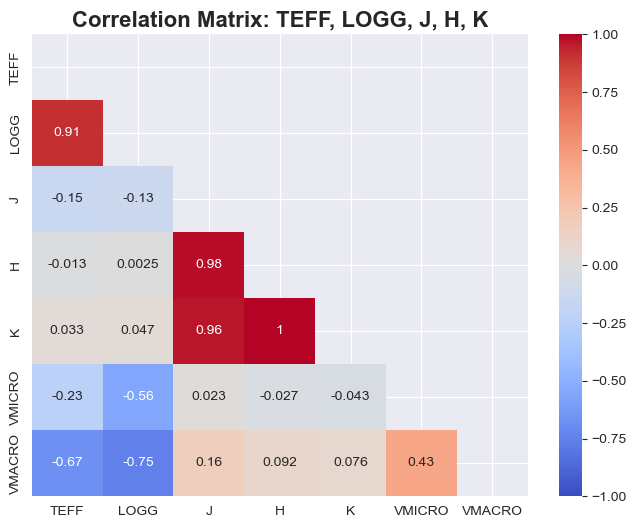

In [18]:
# Calculate correlation between TEFF LOGG, J H K

# Compute the correlation matrix
corr = df_filtered[["TEFF", "LOGG", "J", "H", "K", 'VMICRO', 'VMACRO']].corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
plt.figure(figsize=(8, 6))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix: TEFF, LOGG, J, H, K", fontsize=16, fontweight='bold')
plt.show()


In [39]:
sample_0_miss.columns

Index(['apogee_id', 'J', 'H', 'K', 'LOGG', 'M_H', 'VMICRO', 'VMACRO', 'C_FE',
       'CI_FE', 'N_FE', 'O_FE', 'NA_FE', 'MG_FE', 'AL_FE', 'SI_FE', 'S_FE',
       'K_FE', 'CA_FE', 'TI_FE', 'V_FE', 'CR_FE', 'MN_FE', 'NI_FE', 'FE_H',
       'class_spectral', 'class_lum_logg', 'class_lum_jhk',
       'class_lum_bins_logg', 'class_lum_bins_jhk', 'TEFF'],
      dtype='object')

In [51]:
# Remove unnecessary columns (STARFLAGS and ASPCAPFLAGS)
sample_0_miss = df_filtered.drop(columns=[
    'STARFLAGS', 'ASPCAPFLAGS', 'M_H', 'VMICRO', 'VMACRO', 'class_spectral',
    'class_lum_logg', 'class_lum_jhk', 'class_lum_bins_logg', 'class_lum_bins_jhk'
])

# Define the ID column that should NEVER be scaled
id_column = ["apogee_id"]

# Define the target columns that should be excluded in some cases (TEFF, J, H, K, LOGG)
excluded_targets = ["TEFF", "J", "H", "K", "LOGG"]

# Identify non-numeric columns (these should not be scaled)
non_numeric_cols = sample_0_miss.select_dtypes(exclude=['number']).columns.tolist()

# Identify the columns to be scaled (all numeric columns except apogee_id)
all_numeric_columns = sample_0_miss.select_dtypes(include=['number']).columns.tolist()
columns_to_scale_all = [col for col in all_numeric_columns if col not in id_column]
columns_to_scale_partial = [col for col in all_numeric_columns if col not in id_column + excluded_targets]

### 1. Dataset with Standard Scaling applied to all numeric columns (except apogee_id)
scaler_standard_all = StandardScaler()
sample_standard_all = sample_0_miss.copy()
sample_standard_all[columns_to_scale_all] = scaler_standard_all.fit_transform(sample_standard_all[columns_to_scale_all])
sample_standard_all.to_csv("../../data/resample_standard_all.csv", index=False)

print("✅ Export completed: Standard Scaling applied to all numeric columns.")

### 2. Dataset with Min-Max Scaling applied to all numeric columns (except apogee_id)
scaler_minmax_all = MinMaxScaler()
sample_minmax_all = sample_0_miss.copy()
sample_minmax_all[columns_to_scale_all] = scaler_minmax_all.fit_transform(sample_minmax_all[columns_to_scale_all])
sample_minmax_all.to_csv("../../data/resample_minmax_all.csv", index=False)

print("✅ Export completed: Min-Max Scaling applied to all numeric columns.")

### 3. Dataset with Standard Scaling applied only to selected columns (excluding TEFF, J, H, K, LOGG)
scaler_standard_partial = StandardScaler()
sample_standard_partial = sample_0_miss.copy()
sample_standard_partial[columns_to_scale_partial] = scaler_standard_partial.fit_transform(sample_standard_partial[columns_to_scale_partial])
sample_standard_partial.to_csv("../../data/resample_standard_excluded_targets.csv", index=False)

print("✅ Export completed: Standard Scaling applied excluding TEFF, J, H, K, LOGG.")

### 4. Dataset with Min-Max Scaling applied only to selected columns (excluding TEFF, J, H, K, LOGG)
scaler_minmax_partial = MinMaxScaler()
sample_minmax_partial = sample_0_miss.copy()
sample_minmax_partial[columns_to_scale_partial] = scaler_minmax_partial.fit_transform(sample_minmax_partial[columns_to_scale_partial])
sample_minmax_partial.to_csv("../../data/resample_minmax_excluded_targets.csv", index=False)

print("✅ Export completed: Min-Max Scaling applied excluding TEFF, J, H, K, LOGG.")


✅ Export completed: Standard Scaling applied to all numeric columns.
✅ Export completed: Min-Max Scaling applied to all numeric columns.
✅ Export completed: Standard Scaling applied excluding TEFF, J, H, K, LOGG.
✅ Export completed: Min-Max Scaling applied excluding TEFF, J, H, K, LOGG.


In [52]:
# print all dataset columns and their data types
sample_standard_all.describe()


,J,H,K,LOGG,C_FE,CI_FE,N_FE,O_FE,NA_FE,MG_FE,...,S_FE,K_FE,CA_FE,TI_FE,V_FE,CR_FE,MN_FE,NI_FE,FE_H,TEFF
count,1.757700e+05,1.757700e+05,1.757700e+05,1.757700e+05,1.757700e+05,1.757700e+05,1.757700e+05,1.757700e+05,1.757700e+05,1.757700e+05,...,1.757700e+05,1.757700e+05,1.757700e+05,1.757700e+05,1.757700e+05,1.757700e+05,1.757700e+05,1.757700e+05,1.757700e+05,1.757700e+05
mean,3.246902e-16,2.981717e-16,1.002529e-16,-4.527552e-17,-1.940380e-18,-2.312286e-17,-4.947968e-17,-9.378501e-17,-1.099548e-17,-8.214273e-17,...,4.786270e-17,4.818609e-17,-2.344625e-17,-2.134418e-17,3.732199e-17,-2.684192e-17,-3.864589e-17,9.701898e-18,2.027292e-17,-1.901572e-16
std,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,...,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00
min,-2.525218e+00,-2.293367e+00,-2.216467e+00,-2.634691e+00,-1.176473e+01,-1.118684e+01,-5.439982e+00,-6.492963e+00,-9.569675e+00,-4.867073e+00,...,-5.341707e+00,-1.609824e+01,-1.083921e+01,-5.956574e+00,-1.066531e+01,-1.683854e+01,-1.382371e+01,-1.634500e+01,-5.891766e+00,-1.805647e+00
25%,-7.329008e-01,-7.289388e-01,-7.242143e-01,-6.084639e-01,-5.112563e-01,-5.941779e-01,-4.752648e-01,-7.108483e-01,-2.239339e-01,-6.962133e-01,...,-6.803046e-01,-5.785764e-01,-6.573544e-01,-3.426318e-01,-5.241108e-01,-1.832868e-01,-4.627646e-01,-5.491125e-01,-5.959902e-01,-5.776599e-01
50%,4.236540e-03,3.908243e-02,4.775726e-02,-3.937211e-02,6.123981e-02,1.387645e-02,-3.400825e-02,-2.578983e-01,1.310201e-01,-2.780993e-01,...,-2.532664e-01,-1.092903e-01,-1.791188e-01,1.603541e-02,-4.682921e-02,1.906895e-01,2.059088e-02,3.556974e-02,7.050299e-02,-9.134638e-02
75%,7.272730e-01,7.378162e-01,7.434637e-01,3.890581e-01,6.434905e-01,6.226893e-01,3.829622e-01,6.320371e-01,4.579059e-01,5.170536e-01,...,4.976544e-01,5.841947e-01,4.800297e-01,5.221337e-01,5.838070e-01,4.691896e-01,5.230560e-01,6.288039e-01,7.119306e-01,3.006941e-01
max,2.822749e+00,2.535154e+00,2.472137e+00,2.826367e+00,7.282154e+00,7.893814e+00,9.053184e+00,5.834269e+00,6.445262e+00,5.865084e+00,...,5.904069e+00,7.907960e+00,1.048631e+01,6.310406e+00,8.187993e+00,7.161614e+00,1.708773e+01,8.144830e+00,2.626676e+00,3.911367e+00


In [53]:
sample_standard_partial.describe()

,J,H,K,LOGG,C_FE,CI_FE,N_FE,O_FE,NA_FE,MG_FE,...,S_FE,K_FE,CA_FE,TI_FE,V_FE,CR_FE,MN_FE,NI_FE,FE_H,TEFF
count,175770.000000,175770.000000,175770.000000,175770.000000,1.757700e+05,1.757700e+05,1.757700e+05,1.757700e+05,1.757700e+05,1.757700e+05,...,1.757700e+05,1.757700e+05,1.757700e+05,1.757700e+05,1.757700e+05,1.757700e+05,1.757700e+05,1.757700e+05,1.757700e+05,175770.000000
mean,11.153592,10.499183,10.326642,2.480784,-1.940380e-18,-2.312286e-17,-4.947968e-17,-9.378501e-17,-1.099548e-17,-8.214273e-17,...,4.786270e-17,4.818609e-17,-2.344625e-17,-2.134418e-17,3.732199e-17,-2.684192e-17,-3.864589e-17,9.701898e-18,2.027292e-17,4764.833974
std,1.276564,1.197886,1.180099,0.744119,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,...,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,502.274766
min,7.930000,7.752000,7.711000,0.520265,-1.176473e+01,-1.118684e+01,-5.439982e+00,-6.492963e+00,-9.569675e+00,-4.867073e+00,...,-5.341707e+00,-1.609824e+01,-1.083921e+01,-5.956574e+00,-1.066531e+01,-1.683854e+01,-1.382371e+01,-1.634500e+01,-5.891766e+00,3857.905762
25%,10.218000,9.626000,9.472000,2.028015,-5.112563e-01,-5.941779e-01,-4.752648e-01,-7.108483e-01,-2.239339e-01,-6.962133e-01,...,-6.803046e-01,-5.785764e-01,-6.573544e-01,-3.426318e-01,-5.241108e-01,-1.832868e-01,-4.627646e-01,-5.491125e-01,-5.959902e-01,4474.690796
50%,11.159000,10.546000,10.383000,2.451486,6.123981e-02,1.387645e-02,-3.400825e-02,-2.578983e-01,1.310201e-01,-2.780993e-01,...,-2.532664e-01,-1.092903e-01,-1.791188e-01,1.603541e-02,-4.682921e-02,1.906895e-01,2.059088e-02,3.556974e-02,7.050299e-02,4718.953125
75%,12.082000,11.383000,11.204000,2.770288,6.434905e-01,6.226893e-01,3.829622e-01,6.320371e-01,4.579059e-01,5.170536e-01,...,4.976544e-01,5.841947e-01,4.800297e-01,5.221337e-01,5.838070e-01,4.691896e-01,5.230560e-01,6.288039e-01,7.119306e-01,4915.864624
max,14.757000,13.536000,13.244000,4.583931,7.282154e+00,7.893814e+00,9.053184e+00,5.834269e+00,6.445262e+00,5.865084e+00,...,5.904069e+00,7.907960e+00,1.048631e+01,6.310406e+00,8.187993e+00,7.161614e+00,1.708773e+01,8.144830e+00,2.626676e+00,6729.409180


<Figure size 1500x600 with 0 Axes>

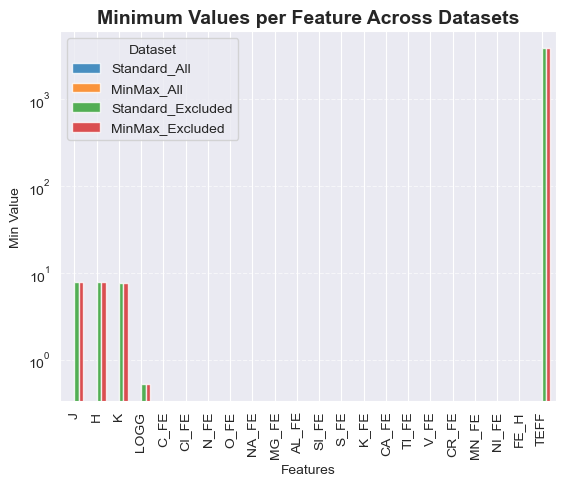

<Figure size 1500x600 with 0 Axes>

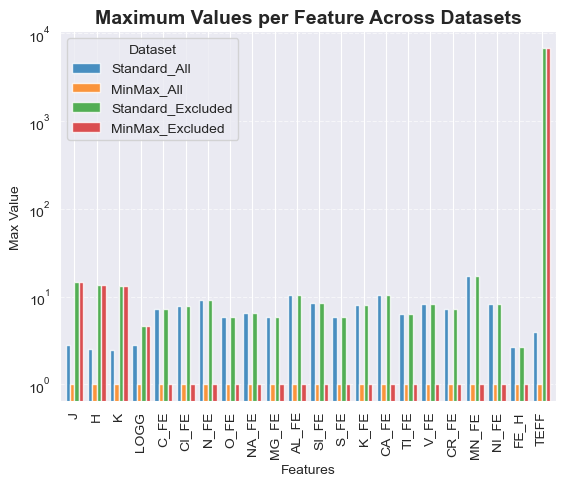

<Figure size 1500x600 with 0 Axes>

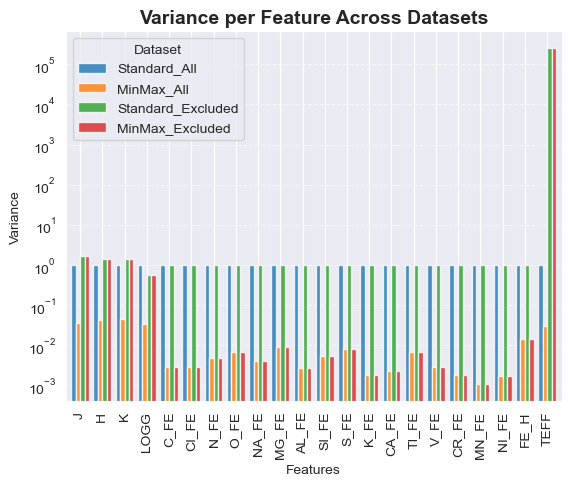

<Figure size 1500x600 with 0 Axes>

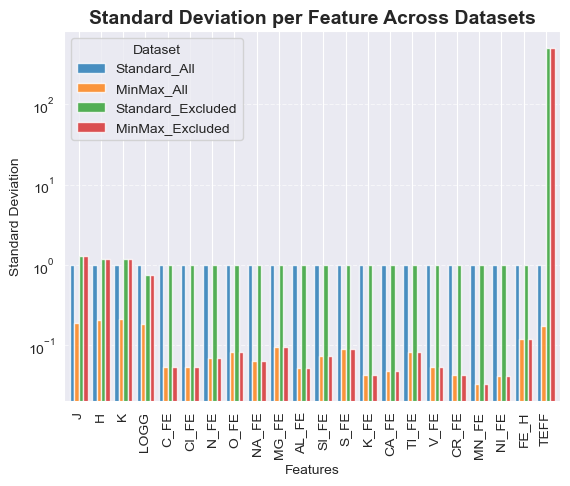

In [61]:
import pandas as pd
import matplotlib.pyplot as plt

# Load datasets
datasets = {
    "Standard_All": pd.read_csv("../../data/resample_standard_all.csv"),
    "MinMax_All": pd.read_csv("../../data/resample_minmax_all.csv"),
    "Standard_Excluded": pd.read_csv("../../data/resample_standard_excluded_targets.csv"),
    "MinMax_Excluded": pd.read_csv("../../data/resample_minmax_excluded_targets.csv"),
}

# Identify numeric columns, excluding "apogee_id"
numeric_cols = [col for col in datasets["Standard_All"].select_dtypes(include=['number']).columns if col != "apogee_id"]

# Create a dictionary to store statistics for each dataset
stats = {stat: pd.DataFrame(index=numeric_cols) for stat in ["Min", "Max", "Variance", "Std"]}

# Compute statistics for each dataset and store them in the dictionary
for name, df in datasets.items():
    stats["Min"][name] = df[numeric_cols].min()
    stats["Max"][name] = df[numeric_cols].max()
    stats["Variance"][name] = df[numeric_cols].var()
    stats["Std"][name] = df[numeric_cols].std()

# Define a function to plot statistics
def plot_stat(df, title, ylabel):
    plt.figure(figsize=(15, 6))
    df.plot(kind='bar', width=0.8, alpha=0.8)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Features")
    plt.ylabel(ylabel)
    plt.semilogy()
    plt.xticks(rotation=90)
    plt.legend(title="Dataset")
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()

# Plot Min, Max, Variance, and Standard Deviation
plot_stat(stats["Min"], "Minimum Values per Feature Across Datasets", "Min Value")
plot_stat(stats["Max"], "Maximum Values per Feature Across Datasets", "Max Value")
plot_stat(stats["Variance"], "Variance per Feature Across Datasets", "Variance")
plot_stat(stats["Std"], "Standard Deviation per Feature Across Datasets", "Standard Deviation")
